In [143]:
!python --version

Python 3.12.13


In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [145]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [146]:
df = pd.read_csv("/content/drive/MyDrive/Bdset/Datasets/Job_2_resource_Weather _Test_Data.csv")

In [147]:
df.head()

,row ID,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,Row0,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No
1,Row1,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No
2,Row2,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,...,24.0,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No
3,Row3,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,...,28.0,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No
4,Row4,Albury,15.9,18.6,15.6,NaN,NaN,W,61.0,NNW,...,28.0,76.0,93.0,994.3,993.0,8.0,8.0,17.4,15.8,Yes


In [148]:
df.shape

(42677, 22)

In [149]:
df.isnull().sum()

,0
row ID,0
Location,0
MinTemp,194
MaxTemp,92
Rainfall,427
Evaporation,18312
Sunshine,20499
WindGustDir,2809
WindGustSpeed,2790
WindDir9am,3007


In [150]:
df.dropna(inplace=True)

In [151]:
df.shape

(16846, 22)

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16846 entries, 1756 to 41701
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row ID         16846 non-null  object 
 1   Location       16846 non-null  object 
 2   MinTemp        16846 non-null  float64
 3   MaxTemp        16846 non-null  float64
 4   Rainfall       16846 non-null  float64
 5   Evaporation    16846 non-null  float64
 6   Sunshine       16846 non-null  float64
 7   WindGustDir    16846 non-null  object 
 8   WindGustSpeed  16846 non-null  float64
 9   WindDir9am     16846 non-null  object 
 10  WindDir3pm     16846 non-null  object 
 11  WindSpeed9am   16846 non-null  float64
 12  WindSpeed3pm   16846 non-null  float64
 13  Humidity9am    16846 non-null  float64
 14  Humidity3pm    16846 non-null  float64
 15  Pressure9am    16846 non-null  float64
 16  Pressure3pm    16846 non-null  float64
 17  Cloud9am       16846 non-null  float64
 18  Cloud3pm

In [153]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.00000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000
mean,13.472652,24.236169,2.053485,5.522237,7.764555,40.845067,15.614864,19.768966,65.882346,49.687582,1017.17730,1014.735154,4.208002,4.285884,18.223762,22.722646
std,6.481411,6.981875,6.990011,3.692763,3.759481,13.379706,8.292799,8.460839,18.419450,20.224100,6.86216,6.815424,2.794741,2.654221,6.611865,6.853896
min,-5.200000,4.100000,0.000000,0.000000,0.000000,9.000000,2.000000,2.000000,1.000000,1.000000,982.20000,977.100000,0.000000,0.000000,-0.700000,3.700000
25%,8.500000,18.700000,0.000000,2.800000,5.100000,31.000000,9.000000,13.000000,55.000000,35.000000,1012.60000,1010.100000,1.000000,2.000000,13.000000,17.300000
50%,13.200000,24.000000,0.000000,5.000000,8.700000,39.000000,15.000000,19.000000,67.000000,51.000000,1017.10000,1014.600000,5.000000,5.000000,17.900000,22.500000
75%,18.500000,29.700000,0.600000,7.500000,10.700000,48.000000,20.000000,26.000000,79.000000,63.000000,1021.80000,1019.300000,7.000000,7.000000,23.300000,27.900000
max,29.700000,46.400000,206.200000,72.200000,14.300000,122.000000,67.000000,61.000000,100.000000,100.000000,1040.40000,1038.900000,8.000000,8.000000,39.400000,45.400000


In [154]:
df.select_dtypes(include="object").columns

Index(['row ID', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday'],
      dtype='object')

In [155]:
df = df.drop(columns=["row ID"], errors='ignore')

In [156]:
df.select_dtypes(include='object').columns

Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'], dtype='object')

In [157]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

for col in categorical_cols:
  df[col] = le.fit_transform(df[col].astype(str))

In [158]:
df.dtypes

,0
Location,int64
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,int64
WindGustSpeed,float64
WindDir9am,int64
WindDir3pm,int64


In [159]:
# Features Selection
X = df.drop("RainToday", axis=1)
y = df["RainToday"]

In [160]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [161]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((11286, 20), (5560, 20), (11286,), (5560,))

# **Before Scaling**

In [162]:
# Implement Baseline model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [163]:
#Prediction model
y_pred = model.predict(X_test)

#                                       **After Scaling**
> Add blockquote



In [164]:
# Apply feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [165]:
# Train model after scaling
model_scaled = LogisticRegression()
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)


In [166]:
# Accuracy compare
from sklearn.metrics import accuracy_score
acc_before = accuracy_score(y_test, y_pred)
acc_after = accuracy_score(y_test, y_pred_scaled)
print("Accuracy before scaling: ", acc_before)
print("Accuracy after scaling: ", acc_after)

Accuracy before scaling:  0.985431654676259
Accuracy after scaling:  0.9879496402877698


In [167]:
# Apply Others 2 model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(random_state=0)
rf = RandomForestClassifier(random_state=0)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [168]:
# Evaluate the model performance
from sklearn.metrics import accuracy_score
logistic = accuracy_score(y_test, y_pred)
dicissiontree = accuracy_score(y_test, dt.predict(X_test))
randomforest = accuracy_score(y_test, rf.predict(X_test))
print("Logistic Regression: ", logistic)
print("Decision Tree: ", dicissiontree)
print("Random Forest: ", randomforest)

Logistic Regression:  0.985431654676259
Decision Tree:  1.0
Random Forest:  1.0


/tmp/ipykernel_6155/3648313263.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


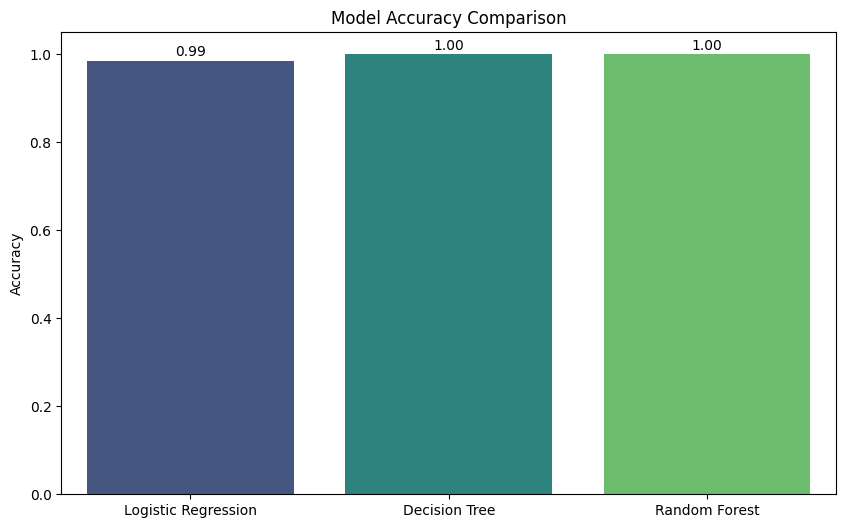

In [177]:
# Visualize model performance
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [logistic, dicissiontree, randomforest]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05) # Set y-axis limit from 0 to 1.05 for accuracy

for index, value in enumerate(accuracies):
    plt.text(index, value + 0.01, f'{value:.2f}', ha='center')

plt.show()

In [175]:
## Overfitting and Underfitting

**Overfitting** occurs when a model learns the training data too well, including the noise and random fluctuations, rather than the underlying pattern. This results in excellent performance on the training data but poor performance on new, unseen data (like your test set). A key sign of overfitting is when training accuracy is very high (e.g., 100%) but testing accuracy is significantly lower.

**Underfitting** occurs when a model is too simple to capture the underlying pattern in the training data. It fails to learn from the training data adequately, leading to poor performance on both training and test data. This can happen if the model is not complex enough or if the features are not representative.

### Relation to Our Models

In our previous run, the Decision Tree and Random Forest models achieved 100% accuracy. This was a strong indicator of **data leakage**, which is a form of 'super-overfitting' where the model inadvertently uses information directly from the target variable during training, making it seem like it's performing perfectly. After removing the `Rainfall` feature (which caused the leakage), the accuracies for these models will likely drop to more realistic levels. If they are still very high on the training set but lower on the test set, it would suggest overfitting. If they are low on both, it could indicate underfitting or that the problem is inherently difficult to predict with the given features.

SyntaxError: unterminated string literal (detected at line 9) (2498714193.py, line 9)

To detect overfitting and underfitting, we need to compare the model's performance on the training data versus its performance on the unseen test data. If the training accuracy is significantly higher than the test accuracy, it's a sign of overfitting. If both accuracies are low, it might indicate underfitting.

In [170]:
# Calculate and display training accuracies

# Logistic Regression (unscaled)
y_train_pred_logistic = model.predict(X_train)
train_acc_logistic = accuracy_score(y_train, y_train_pred_logistic)

# Logistic Regression (scaled)
y_train_pred_logistic_scaled = model_scaled.predict(X_train_scaled)
train_acc_logistic_scaled = accuracy_score(y_train, y_train_pred_logistic_scaled)

# Decision Tree
y_train_pred_dt = dt.predict(X_train)
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)

# Random Forest
y_train_pred_rf = rf.predict(X_train)
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)

print("Training Accuracy (Logistic Regression, unscaled): ", train_acc_logistic)
print("Training Accuracy (Logistic Regression, scaled): ", train_acc_logistic_scaled)
print("Training Accuracy (Decision Tree): ", train_acc_dt)
print("Training Accuracy (Random Forest): ", train_acc_rf)

print("\nTest Accuracies (from previous run for comparison):")
print("Test Accuracy (Logistic Regression, unscaled): ", logistic)
print("Test Accuracy (Logistic Regression, scaled): ", acc_after)
print("Test Accuracy (Decision Tree): ", dicissiontree)
print("Test Accuracy (Random Forest): ", randomforest)

Training Accuracy (Logistic Regression, unscaled):  0.9852029062555379
Training Accuracy (Logistic Regression, scaled):  0.9905192273613326
Training Accuracy (Decision Tree):  1.0
Training Accuracy (Random Forest):  1.0

Test Accuracies (from previous run for comparison):
Test Accuracy (Logistic Regression, unscaled):  0.985431654676259
Test Accuracy (Logistic Regression, scaled):  0.9879496402877698
Test Accuracy (Decision Tree):  1.0
Test Accuracy (Random Forest):  1.0


In [176]:
# Save the  model
import joblib

# Save Logistic Regression model
joblib.dump(model, 'logistic_regression_model.joblib')
joblib.dump(model_scaled, 'logistic_regression_scaled_model.joblib')

# Save the Random Forest model
joblib.dump(rf, 'random_forest_model.joblib')

# Save the Dicission Tree model
joblib.dump(dt, 'dicission_tree_model.joblib')

print("Random Forest model saved as 'random_forest_model.joblib'")


Random Forest model saved as 'random_forest_model.joblib'
